# **Laboratorio 1**

---

### Lucía Coudet, Cecilia Waksman

---

# Carga de librerías y verificado de versiones (Python 3.12 y scikit-learn 1.9)

In [ ]:
# %pip install scikit-learn==1.9.0

In [1]:
import numpy as np
import pandas as pd
import sklearn
import sklearn.preprocessing
import sklearn.feature_selection
pd.options.mode.chained_assignment ='warn' # default='warn'
import graphviz

In [2]:
import sys

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
scikit-learn: 1.6.1


# Carga y visualización del dataset

In [28]:
#Leemos los datos
#En https://github.com/schochastics/football-data está el repo original con los datos completos y la documnetación
datos=pd.read_csv('futbol_uruguayo.csv')
datos.head(2)

,home,away,date,gh,ga,full_time,competition,home_ident,away_ident,home_country,away_country,home_code,away_code,home_continent,away_continent,continent,level
0,Bella Vista,Defensor Sporting,1932-03-05,1.0,2.0,F,uruguay,Bella Vista (Uruguay),Defensor Sporting (Uruguay),uruguay,uruguay,UY,UY,South America,South America,South America,national
1,CA Penarol,River Plate,1932-03-05,1.0,1.0,F,uruguay,CA Penarol (Uruguay),River Plate (Uruguay),uruguay,uruguay,UY,UY,South America,South America,South America,national


In [ ]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 15207 entries, 0 to 15206
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   home            15207 non-null  str    
 1   away            15207 non-null  str    
 2   date            15207 non-null  str    
 3   gh              15207 non-null  float64
 4   ga              15207 non-null  float64
 5   full_time       15207 non-null  str    
 6   competition     15207 non-null  str    
 7   home_ident      15207 non-null  str    
 8   away_ident      15207 non-null  str    
 9   home_country    15207 non-null  str    
 10  away_country    15207 non-null  str    
 11  home_code       15207 non-null  str    
 12  away_code       15207 non-null  str    
 13  home_continent  15207 non-null  str    
 14  away_continent  15207 non-null  str    
 15  continent       15207 non-null  str    
 16  level           15207 non-null  str    
dtypes: float64(2), str(15)
memory usage: 2.0 M

---

# 1. PREPROCESAMIENTO

## - Definimos tipo de los atributos

## - Eliminamos atributos que cuentan con 1 solo valor (Uruguay, UY, South America, national)
## - Eliminamos atributos **repetidos**
## - Eliminamos atributos que pueden presentar *data leakage*

(`full_time` puede presentar *data leakage*. Si se va a penales, se podría suponer que el partido no puede tener como resultado un empate).

In [ ]:
atributos = pd.DataFrame(datos)
print(atributos.nunique())

home                38
away                38
date              3816
gh                  11
ga                  10
full_time            3
competition          1
home_ident          38
away_ident          38
home_country         1
away_country         1
home_code            1
away_code            1
home_continent       1
away_continent       1
continent            1
level                1
dtype: int64


In [ ]:
# Verificamos que solo cuenta con valores enteros
print(datos['gh'].unique())
print(datos['ga'].unique())
print(datos["full_time"].unique()) # El partido terminó: F = en los 90 minutos reglamentarios, E	= en tiempo extra/prórroga, P	= mediante definición por penales

[ 1.  3.  2.  6.  4.  7.  0.  5.  8. 10.  9.]
[2. 1. 0. 3. 4. 5. 6. 7. 8. 9.]
<StringArray>
['F', 'P', 'E']
Length: 3, dtype: str


In [ ]:
# Verificamos que los atributos identificadores de home y away no agregan información extra, ya que toman los mismos valores
pd.DataFrame({
    'home': datos['home'].unique(),
    'home_ident': datos['home_ident'].unique(),
    'away': datos['away'].unique(),
    'away_ident': datos['away_ident'].unique()
})

,home,home_ident,away,away_ident
0,Bella Vista,Bella Vista (Uruguay),Defensor Sporting,Defensor Sporting (Uruguay)
1,CA Penarol,CA Penarol (Uruguay),River Plate,River Plate (Uruguay)
2,Montevideo Wanderers,Montevideo Wanderers (Uruguay),Racing Club,Racing Club (Uruguay)
3,Central Espanol,Central Espanol (Uruguay),Rampla Juniors Futbol Club,Rampla Juniors Futbol Club (Uruguay)
4,Nacional,Nacional (Uruguay),Institucion Atletica Sud America,Institucion Atletica Sud America (Uruguay)
5,Defensor Sporting,Defensor Sporting (Uruguay),Bella Vista,Bella Vista (Uruguay)
6,Rampla Juniors Futbol Club,Rampla Juniors Futbol Club (Uruguay),Central Espanol,Central Espanol (Uruguay)
7,Racing Club,Racing Club (Uruguay),Nacional,Nacional (Uruguay)
8,River Plate,River Plate (Uruguay),Montevideo Wanderers,Montevideo Wanderers (Uruguay)
9,Institucion Atletica Sud America,Institucion Atletica Sud America (Uruguay),CA Penarol,CA Penarol (Uruguay)


In [29]:
# Categóricos
datos["home"] = datos["home"].astype("category")
datos["away"] = datos["away"].astype("category")

# Fechas
datos["date"] = pd.to_datetime(datos["date"])

# Numericos tipo float a enteros
datos["gh"] = datos["gh"].astype(int)
datos["ga"] = datos["ga"].astype(int)

datos = datos.drop(columns=['competition',
                            'home_ident',
                            'away_ident',
                            'home_country',
                            'away_country',
                            'home_code',
                            'away_code',
                            'home_continent',
                            'away_continent',
                            'continent',
                            'level',
                            'full_time'])

## - Creamos la variable de salida "resultado"



In [30]:
# CREAMOS LA VARIABLE DE SALIDA "RESULTADO"

# Definimos las condiciones
condiciones = [
    datos["gh"] > datos["ga"],  # Gana el local
    datos["gh"] < datos["ga"],  # Gana el visitante
]

# Definimos los resultados para cada condición
opciones = ["L", "V"] # "gana el local", "gana el visitante"

# Aplicamos las condiciones; si no se cumple ninguna (son iguales), asigna "hay empate"
datos["resultado"] = np.select(condiciones, opciones, default="E") # "hay empate"

datos["resultado"] = datos["resultado"].astype("category")

# Ejemplo de visualización
datos[["gh", "ga", "resultado"]].head(2)

,gh,ga,resultado
0,1,2,V
1,1,1,E


## - Eliminamos filas duplicadas
## - Detectamos datos faltantes (no hay)

In [31]:
# ELIMINAMOS FILAS DUPLICADAS
cant_duplicados = datos.duplicated().sum()
print(f"Filas duplicadas encontradas: {cant_duplicados}")
datos = datos.drop_duplicates()

# DETECTAMOS DATOS FALTANTES E IMPUTAMOS MEDIA - no hay valores faltantes

print("\nValores faltantes por columna:")
print(datos.isnull().sum())


Filas duplicadas encontradas: 1

Valores faltantes por columna:
home         0
away         0
date         0
gh           0
ga           0
resultado    0
dtype: int64


## - Creamos nuevos atributos a partir de "date"
## - Eliminamos atributos que tengan información sobre el resultado

In [32]:
# Creamos nuevos atributos para usar en el algoritmo a partir del atributo fecha

# Extraer componentes temporales relevantes:

# Año (para capturar tendencias históricas, ej: evolución del fútbol con las décadas)
datos["year"] = datos["date"].dt.year

# Mes y Trimestre (para capturar estacionalidad en el torneo)
datos["month"] = datos["date"].dt.month

# Día de la semana (0=Lunes, 6=Domingo; útil para ver si se juega fin de semana o entre semana)
datos["dayofweek"] = datos["date"].dt.dayofweek

# Indicador de si es fin de semana (1 si es Sábado/Domingo, 0 si no)
datos["is_weekend"] = datos["dayofweek"].isin([5, 6]).astype(int)

datos = datos.drop(columns=['gh', 'ga'])

## - Ordenamos los datos para partición posterior
## - Agregamos atributos: tasa de victoria en los últimos 5 partidos del local y del visitante, diferencia de las tasas de victoria.

In [33]:

# Asegurar el orden cronológico del DataFrame usando las columnas de fecha disponibles
datos = datos.sort_values("date").reset_index(drop=True)

# Identificador de cada partido
datos["id_partido"] = datos.index

# Crear registros para local y visitante
home_df = datos[["id_partido", "date", "home", "resultado"]].rename(
    columns={"home": "equipo"})
home_df["condicion"] = "home"
home_df["ganado"] = (home_df["resultado"] == "L").astype(int)

away_df = datos[["id_partido", "date", "away", "resultado"]].rename(
    columns={"away": "equipo"})
away_df["condicion"] = "away"
away_df["ganado"] = (away_df["resultado"] == "V").astype(int)

# Unir dfs
historial = pd.concat([home_df, away_df],ignore_index=True)

# Ordenar nuevamente por fecha
historial = historial.sort_values(["date", "id_partido"]).reset_index(drop=True)

# Calcular tasa de victorias en los últimos 5 partidos
N = 5
historial["tasa_victorias"] = (historial
    .groupby("equipo")["ganado"]
    .transform(lambda x: x.shift(1)
                   .rolling(window=N, min_periods=1)
                   .mean())
    .fillna(0))

# Separar nuevamente local y visitante
tasas_home = (
    historial[historial["condicion"] == "home"]
    [["id_partido", "tasa_victorias"]]
.rename(columns={"tasa_victorias": "home_tasa_victorias"}))

tasas_away = (
    historial[historial["condicion"] == "away"]
    [["id_partido", "tasa_victorias"]]
    .rename(columns={"tasa_victorias": "away_tasa_victorias"}))

# Incorporar las tasas al DataFrame original
datos = datos.merge(tasas_home, on="id_partido", how="left")
datos = datos.merge(tasas_away, on="id_partido", how="left")

# Crear e incorporar la diferencia entre la tasa del local y la del visitante
datos["dif_tasa_victorias"] = (
    datos["home_tasa_victorias"] - datos["away_tasa_victorias"]
)

# Verificación de las variables agregadas
print(datos[['home', 'away', 'date', 'resultado', 'home_tasa_victorias', 'away_tasa_victorias', 'dif_tasa_victorias']].tail(10))


                    home                  away       date resultado  \
15196     Cerro Largo FC         Plaza Colonia 2025-06-23         V   
15197       Boston River             Torque FC 2025-06-23         L   
15198         CA Penarol              CA Cerro 2025-06-28         L   
15199       Boston River      Miramar Misiones 2025-06-28         V   
15200          Liverpool  Montevideo Wanderers 2025-06-28         V   
15201  Defensor Sporting         Plaza Colonia 2025-06-28         E   
15202        Racing Club             Torque FC 2025-06-29         E   
15203           Nacional               Danubio 2025-06-29         L   
15204        CA Juventud           CA Progreso 2025-06-29         L   
15205     Cerro Largo FC           River Plate 2025-06-30         E   

       home_tasa_victorias  away_tasa_victorias  dif_tasa_victorias  
15196                  0.0                  0.0                 0.0  
15197                  0.2                  0.2                 0.0  
15198   

/tmp/ipykernel_250/2705877515.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("equipo")["ganado"]


## - Verificamos que las fechas se encuentren dentro del rango esperado (1932-2025)

In [34]:
#Verificamos que las fechas de los partidos se encuentren dentro del rango esperado (1932-2025)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline


class ValidadorRangoAnioNum(BaseEstimator, TransformerMixin):
    """Transformador que valida que una o varias columnas con valores numéricos de año

    estén dentro del rango especificado [anio_min, anio_max].
    """

    def __init__(
        self,
        columnas_anio,
        anio_min=1932,
        anio_max=2032,
        lanzar_error=False,
    ):
        self.columnas_anio = columnas_anio
        self.anio_min = anio_min
        self.anio_max = anio_max
        self.lanzar_error = lanzar_error

    def fit(self, X, y=None):
        return self  # No requiere aprendizaje

    def transform(self, X):
        X_copy = X.copy()

        for col in self.columnas_anio:
            años = X_copy[col]

            # Filtrar valores fuera del rango o nulos
            invalidos = X_copy[
                (años < self.anio_min) | (años > self.anio_max) | años.isna()
            ]

            if not invalidos.empty:
                mensaje = (
                    f"⚠️ Se encontraron {len(invalidos)} registros fuera del "
                    f"rango ({self.anio_min} - {self.anio_max}) en la columna '{col}'."
                )
                if self.lanzar_error:
                    raise ValueError(mensaje)
                else:
                    print(mensaje)
                    print(invalidos[[col]])

        return X_copy


# ---------------------------------------------------------

# Definimos el pipeline
pipeline_validacion = Pipeline(
    [
        (
            "validador_anio",
            ValidadorRangoAnioNum(
                columnas_anio=["year"],
                anio_min=1932,
                anio_max=2025,
                lanzar_error=False,  # Cambiar a True para detener el script ante anomalías
            ),
        )
    ]
)

# Ejecutar el pipeline
datos = pipeline_validacion.fit_transform(datos)

In [ ]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 15206 entries, 0 to 15205
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   home                 15206 non-null  category      
 1   away                 15206 non-null  category      
 2   date                 15206 non-null  datetime64[us]
 3   resultado            15206 non-null  category      
 4   year                 15206 non-null  int32         
 5   month                15206 non-null  int32         
 6   dayofweek            15206 non-null  int32         
 7   is_weekend           15206 non-null  int64         
 8   id_partido           15206 non-null  int64         
 9   home_tasa_victorias  15206 non-null  float64       
 10  away_tasa_victorias  15206 non-null  float64       
 11  dif_tasa_victorias   15206 non-null  float64       
dtypes: category(3), datetime64[us](1), float64(3), int32(3), int64(2)
memory usage: 936.4 KB


---

# 2. MODELOS SUPERVISADOS

Comentarios:  ⁠
- Falta features selection

---
- Para el Árbol yo implementaría OneHot y para el CategoricalNB OrdinalEncoder (pasar categorías a enteros)
- Revisar warning en métricas del árbol: no está prediciendo en ningún caso uno de las categorías de respuesta. No implica que esté mal.
- En el NB el "m" no es exactamente lo mismo que "alpha".
---

## - Paricionamos de los datos: 1932 - 2023 inclusive para train, 2024 y 2025 para test

In [35]:
from sklearn.model_selection import train_test_split

# Ordenar por fecha cronológicamente
datos = datos.sort_values(by=["date"]).reset_index(
    drop=True
)

# Separar características (X) conservando temporalmente la columna 'year'
datos_x = datos.drop(columns=["resultado"])
datos_y = datos[["resultado"]]

# Crear máscaras booleanas para la partición por años
mask_train = datos_x["year"] <= 2023
mask_test = datos_x["year"].isin([2024, 2025])

# 4. Dividir los conjuntos de datos según los años
X_train = datos_x[mask_train].copy()
X_test = datos_x[mask_test].copy()

y_train = datos_y[mask_train].copy()
y_test = datos_y[mask_test].copy()

# (Opcional) Verificación de la cantidad de registros por conjunto
print(f"Registros de entrenamiento (<= 2023): {len(X_train)}")
print(f"Registros de evaluación (2024-2025): {len(X_test)}")

display(X_train.head(5))
display(y_train.head(5))
display(X_train.shape)
display(y_train.shape)


Registros de entrenamiento (<= 2023): 14734
Registros de evaluación (2024-2025): 472


,home,away,date,year,month,dayofweek,is_weekend,id_partido,home_tasa_victorias,away_tasa_victorias,dif_tasa_victorias
0,Bella Vista,Defensor Sporting,1932-03-05,1932,3,5,1,0,0.0,0.0,0.0
1,CA Penarol,River Plate,1932-03-05,1932,3,5,1,1,0.0,0.0,0.0
2,Montevideo Wanderers,Racing Club,1932-03-05,1932,3,5,1,2,0.0,0.0,0.0
3,Central Espanol,Rampla Juniors Futbol Club,1932-03-05,1932,3,5,1,3,0.0,0.0,0.0
4,Nacional,Institucion Atletica Sud America,1932-03-05,1932,3,5,1,4,0.0,0.0,0.0


,resultado
0,V
1,E
2,L
3,L
4,L


(14734, 11)

(14734, 1)

---

## **Feature Selection**

## - Mutual information/ Ganancia de información mide cuánto puede explicar un atributo de X al atributo y **individualmente**.
Para atributos categóricos: es la misma Ganancia que calculamos en la partición de los árboles. Se usa OrdinalEncoder porque necesita entradas numéricas
Para atributos numéricos: el estimador está basado en vecinos más cercanos.

In [11]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

features_selection = [
    "year",
    "month",
    "dayofweek",
    "is_weekend",
    "home_tasa_victorias",
    "away_tasa_victorias",
    "dif_tasa_victorias",
    "home",
    "away"
]

X_fs = X_train[features_selection].copy()
y_fs = y_train["resultado"].copy()

categorical_fs = [
    "month",
    "dayofweek",
    "is_weekend",
    "home",
    "away"
]

numeric_fs = [
    "year",
    "home_tasa_victorias",
    "away_tasa_victorias",
    "dif_tasa_victorias"
]

In [12]:
# Se usa OrdinalEncoder porque necesita entradas numéricas
encoder_fs = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_fs[categorical_fs] = encoder_fs.fit_transform(
    X_fs[categorical_fs]
)

# lista de True y False segun si el atributo es o no categórico
discrete_features = [
    col in categorical_fs
    for col in X_fs.columns
]

# calcula la ganancia de cada atributo
mi = mutual_info_classif(
    X_fs,
    y_fs,
    discrete_features=discrete_features,
    random_state=42
)

importancia_mi = pd.DataFrame({
    "variable": X_fs.columns,
    "mutual_information": mi
}).sort_values(
    "mutual_information",
    ascending=False
)

print(importancia_mi)

              variable  mutual_information
7                 home            0.038124
8                 away            0.034843
6   dif_tasa_victorias            0.029928
5  away_tasa_victorias            0.020861
1                month            0.020830
0                 year            0.019960
4  home_tasa_victorias            0.017992
2            dayofweek            0.003722
3           is_weekend            0.000867


## - Eliminamos atribitos que aportan menos de un 0.01 unidades de ganancia.

Antes se verifició que no se usen en Árbol de sklearn que se entrena en las siguientes secciones.

In [42]:
X_train = X_train.drop(columns=["dayofweek", "is_weekend"])
X_test = X_test.drop(columns=["dayofweek", "is_weekend"])


## **Árbol de Clasificación**

---

## - One Hot Encoder para atributos categóricos

In [43]:
#defino transformacion segun tipo columna
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = ["home", "away", "month"]
num_cols = ["home_tasa_victorias", "away_tasa_victorias", "dif_tasa_victorias"]

# Definir las transformaciones por tipo de columna
preprocessor_arbol = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_cols),
        ('num', 'passthrough', num_cols) # 'passthrough' mantiene las variables numéricas tal como están
        # O podrías usar StandardScaler() si prefieres escalarlas:
        # ('num', StandardScaler(), num_cols)
        # si no pongo nada sobre "date", esa columna se dropea automáticamente
    ]
)

# Ajustar y transformar
X_train_encoded_arbol = preprocessor_arbol.fit_transform(X_train)
X_test_encoded_arbol = preprocessor_arbol.transform(X_test)

# ahora convertimos a Y en categorica para ahorrar memoria, aunque no es estrictamente neesario
mapa_resultados = {
    "L": 0,
    "V": 1,
    "E": 2,
}

# Seleccionamos la columna 'resultado'
y_train_encoded = y_train["resultado"].map(mapa_resultados)
y_test_encoded = y_test["resultado"].map(mapa_resultados)

In [44]:
#IMPLEMENTACION MANUAL DEL ARBOL DE DECISION - ALGORITMO
from sklearn.base import BaseEstimator, ClassifierMixin


class NodoDecision:

    def __init__(
        self,
        columna=None,
        umbral=None,
        izquierda=None,
        derecha=None,
        *,
        valor=None,
    ):
        self.columna = columna
        self.umbral = umbral
        self.izquierda = izquierda
        self.derecha = derecha
        self.valor = valor

    def es_hoja(self):
        return self.valor is not None


class ArbolDecisionManual(BaseEstimator, ClassifierMixin):

    def __init__(self, min_info_gain=0.01, max_depth=None):
        self.min_info_gain = min_info_gain
        self.max_depth = max_depth
        self.raiz = None

    def _entropia(self, y):
        clases, conteos = np.unique(y, return_counts=True)
        probabilidades = conteos / len(y)
        return -np.sum([p * np.log2(p) for p in probabilidades if p > 0])

    def _dividir(self, X, y, col_idx, umbral):
        val = X.iloc[:, col_idx] if isinstance(X, pd.DataFrame) else X[:, col_idx]

        if isinstance(umbral, (int, float, np.number)):
            masca_izq = val <= umbral
        else:
            masca_izq = val == umbral

        masca_der = ~masca_izq
        return (
            X[masca_izq],
            y[masca_izq],
            X[masca_der],
            y[masca_der],
        )

    def _ganancia_informacion(self, y, X, col_idx, umbral):
        entropia_padre = self._entropia(y)
        _, y_izq, _, y_der = self._dividir(X, y, col_idx, umbral)

        if len(y_izq) == 0 or len(y_der) == 0:
            return 0

        n = len(y)
        n_izq, n_der = len(y_izq), len(y_der)
        e_izq, e_der = self._entropia(y_izq), self._entropia(y_der)
        entropia_hijos = (n_izq / n) * e_izq + (n_der / n) * e_der

        return entropia_padre - entropia_hijos

    def _mejor_division(self, X, y):
        mejor_ganancia = -1
        col_optima, umbral_optimo = None, None
        num_columnas = X.shape[1]

        for col_idx in range(num_columnas):
            valores = (
                X.iloc[:, col_idx]
                if isinstance(X, pd.DataFrame)
                else X[:, col_idx]
            )
            umbrales_posibles = np.unique(valores)

            for umbral in umbrales_posibles:
                ganancia = self._ganancia_informacion(
                    y, X, col_idx, umbral
                )

                if ganancia > mejor_ganancia:
                    mejor_ganancia = ganancia
                    col_optima = col_idx
                    umbral_optimo = umbral

        return col_optima, umbral_optimo, mejor_ganancia

    def _construir_arbol(self, X, y, profundidad=0):
        n_muestras, n_clases = len(y), len(np.unique(y))

        # Validación de profundidad máxima considerando None
        alcanzo_max_depth = (
            self.max_depth is not None and profundidad >= self.max_depth
        )

        if (
            n_clases == 1
            or alcanzo_max_depth
            or n_muestras < 2
        ):
            clase_mas_comun = (
                pd.Series(y).mode()[0]
                if len(y) > 0
                else None
            )
            return NodoDecision(valor=clase_mas_comun)

        col_opt, umbral_opt, ganancia = self._mejor_division(X, y)

        if ganancia < self.min_info_gain:
            clase_mas_comun = pd.Series(y).mode()[0]
            return NodoDecision(valor=clase_mas_comun)

        X_izq, y_izq, X_der, y_der = self._dividir(
            X, y, col_opt, umbral_opt
        )
        hijo_izq = self._construir_arbol(
            X_izq, y_izq, profundidad + 1
        )
        hijo_der = self._construir_arbol(
            X_der, y_der, profundidad + 1
        )

        return NodoDecision(
            columna=col_opt,
            umbral=umbral_opt,
            izquierda=hijo_izq,
            derecha=hijo_der,
        )

    def fit(self, X, y):
        y = np.asarray(y).ravel()
        self.classes_ = np.unique(y)
        self.raiz = self._construir_arbol(X, y)
        return self

    def _predecir_fila(self, nodo, x):
        if nodo.es_hoja():
            return nodo.valor

        valor_x = x.iloc[nodo.columna] if isinstance(x, pd.Series) else x[nodo.columna]

        if isinstance(nodo.umbral, (int, float, np.number)):
            if valor_x <= nodo.umbral:
                return self._predecir_fila(nodo.izquierda, x)
            return self._predecir_fila(nodo.derecha, x)
        else:
            if valor_x == nodo.umbral:
                return self._predecir_fila(nodo.izquierda, x)
            return self._predecir_fila(nodo.derecha, x)

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            return np.array(
                [self._predecir_fila(self.raiz, row) for _, row in X.iterrows()]
            )
        return np.array([self._predecir_fila(self.raiz, row) for row in X])

In [45]:
#IMPLEMENTACION MANUAL DEL ARBOL DE DECISION - AJUSTE
from sklearn.metrics import accuracy_score, classification_report


X_tr_manual = X_train_encoded_arbol
X_te_manual = X_test_encoded_arbol

# Instanciar el árbol con el hiperparámetro de ganancia mínima (0.01) y max depth 5
arbol_manual = ArbolDecisionManual(min_info_gain=0.01, max_depth=None)  # Cambié max_depth a None para permitir crecimiento completo

# Entrenar el modelo
arbol_manual.fit(X_tr_manual, y_train_encoded)

# Generar predicciones sobre el conjunto de test
y_pred_manual = arbol_manual.predict(X_te_manual)

# Métricas de evaluación
print(
    f"Accuracy Árbol Manual: {accuracy_score(y_test_encoded, y_pred_manual):.4f}\n"
)
print(classification_report(y_test_encoded, y_pred_manual))

Accuracy Árbol Manual: 0.4364

              precision    recall  f1-score   support

           0       0.42      0.93      0.58       190
           1       0.65      0.19      0.29       151
           2       0.14      0.01      0.01       131

    accuracy                           0.44       472
   macro avg       0.40      0.37      0.29       472
weighted avg       0.42      0.44      0.33       472



## - Implementamos el Árbol de Decisión de sklearn

In [46]:

# IMPLEMENTACIÓN DEL ÁRBOL DE DECISIÓN CON GANANCIA MÍNIMA DE INFORMACIÓN
# UTILIZANDO LA LIBRERIA SCIKIT-LEARN

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# Defina el valor de la ganancia mínima de información deseada
min_info_gain = 0.01

# Inicializar el Árbol de Decisión:
# - criterion='entropy': calcula la Ganancia de Información (Information Gain)
# - min_impurity_decrease=min_info_gain: detiene la división cuando la ganancia es menor al valor especificado
arbol_modelo = DecisionTreeClassifier(
    criterion="entropy", min_impurity_decrease=min_info_gain, max_depth=None, random_state=42
)

# Entrenar el modelo
arbol_modelo.fit(X_train_encoded_arbol, y_train_encoded)

# EVALUACIÓN DEL MODELO SOBRE EL CONJUNTO DE PRUEBA

y_pred = arbol_modelo.predict(X_test_encoded_arbol)

print(
    f"=== Árbol de Decisión (min_info_gain = {min_info_gain}) ==="
)
print(f"Exactitud (Accuracy): {accuracy_score(y_test_encoded, y_pred):.4f}\n")

print("Reporte de Clasificación:")
print(classification_report(y_test_encoded, y_pred))


=== Árbol de Decisión (min_info_gain = 0.01) ===
Exactitud (Accuracy): 0.4534

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.48      0.73      0.58       190
           1       0.42      0.50      0.46       151
           2       0.00      0.00      0.00       131

    accuracy                           0.45       472
   macro avg       0.30      0.41      0.34       472
weighted avg       0.33      0.45      0.38       472



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


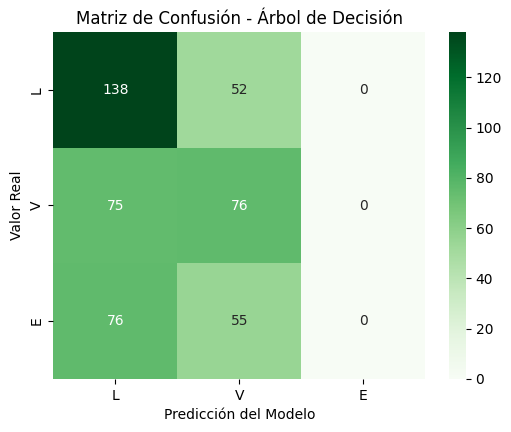

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generar la matriz usando y_test_encoded y los índices numéricos [0, 1, 2]
cm = confusion_matrix(y_test_encoded, y_pred, labels=[0, 1, 2])

# 2. Si definiste un LabelEncoder llamado 'le', podemos obtener el orden exacto de las clases:
# etiquetas_visibles = le.classes_  # Ejemplo: ['E', 'L', 'V']
# O si prefieres forzar el texto fijo en ese orden:
etiquetas_visibles = ["L", "V", "E"]

plt.figure(figsize=(6, 4.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=etiquetas_visibles,
    yticklabels=etiquetas_visibles,
)
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Valor Real")
plt.show()

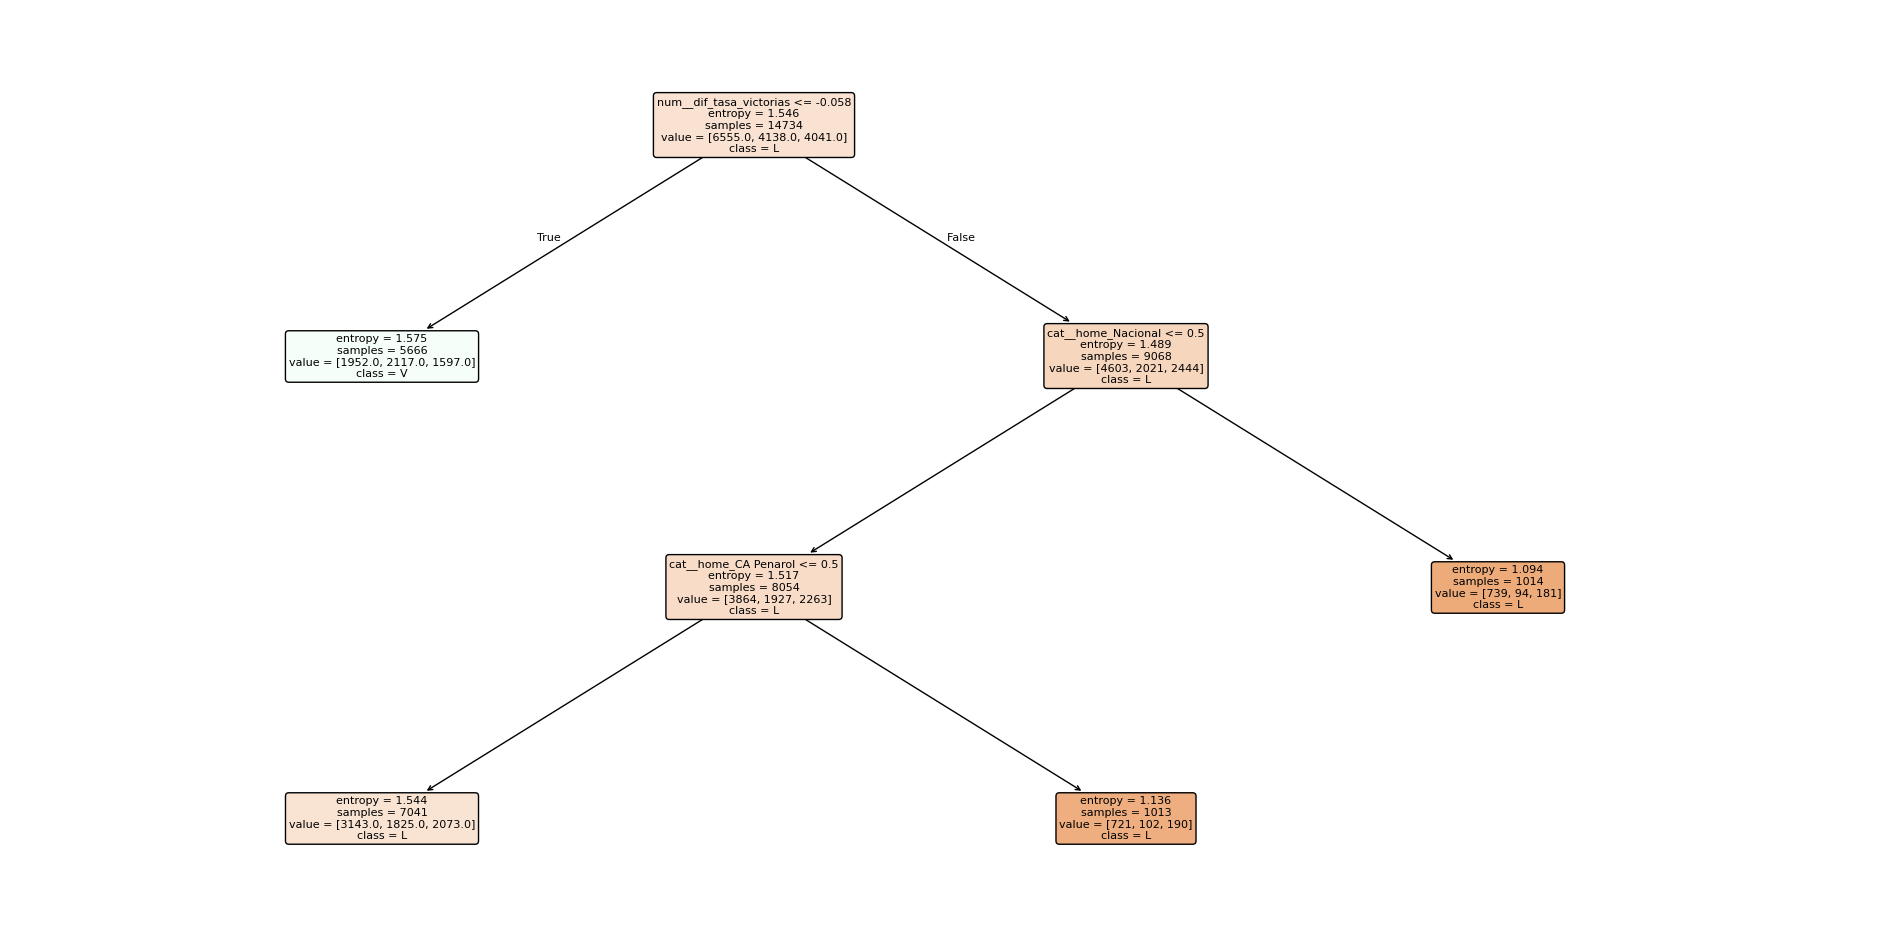

In [48]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

feature_names = preprocessor_arbol.get_feature_names_out()

mapa_inverso = {
    0: "L",
    1: "V",
    2: "E"
}

class_names = [
    mapa_inverso[c]
    for c in arbol_modelo.classes_
]

plt.figure(figsize=(24, 12))

plot_tree(
    arbol_modelo,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

Se verifica que la clase 2 "Hay empate" tiene precision y recall 0. Esto puede deberse a:

- Desbalance severo de clases: La clase con 0 accuracy representa un porcentaje muy pequeño del conjunto de datos y el árbol la ignora para maximizar el accuracy global.

- El árbol está sobreajustado o simplificado en exceso: Los parámetros por defecto dejan que el árbol crezca tanto que memoriza el ruido de las clases mayoritarias, o está tan podado (max_depth muy bajo) que elimina ramas de clases minoritarias.

- Métrica de optimización incorrecta: Estás usando accuracy como criterio de optimización, el cual prioriza a las clases con más muestras.

Se propone balancear el peso de las clases utilizando el argumento class_weight='balanced', esto le da más importancia (penalización) a los errores cometidos en las clases con menos muestras.

In [51]:
# IMPLEMENTACIÓN DEL ÁRBOL DE DECISIÓN CON GANANCIA MÍNIMA DE INFORMACIÓN
# Y DATOS BALANCEADOS


from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# Defina el valor de la ganancia mínima de información deseada
min_info_gain = 0.01

# Inicializar el Árbol de Decisión:
# - criterion='entropy': calcula la Ganancia de Información (Information Gain)
# - min_impurity_decrease=min_info_gain: detiene la división cuando la ganancia es menor al valor especificado
arbol_modelo_balanceado = DecisionTreeClassifier(class_weight="balanced",
    criterion="entropy", min_impurity_decrease=min_info_gain, random_state=42
)

# Entrenar el modelo
arbol_modelo_balanceado.fit(X_train_encoded_arbol, y_train_encoded)

# ==============================================================================
# EVALUACIÓN DEL MODELO SOBRE EL CONJUNTO DE PRUEBA
# ==============================================================================
y_pred = arbol_modelo_balanceado.predict(X_test_encoded_arbol)

print(
    f"=== Árbol de Decisión (min_info_gain = {min_info_gain}) ==="
)
print(f"Exactitud (Accuracy): {accuracy_score(y_test_encoded, y_pred):.4f}\n")

print("Reporte de Clasificación:")
print(classification_report(y_test_encoded, y_pred))


=== Árbol de Decisión (min_info_gain = 0.01) ===
Exactitud (Accuracy): 0.3835

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.74      0.21      0.33       190
           1       0.42      0.50      0.46       151
           2       0.28      0.50      0.36       131

    accuracy                           0.38       472
   macro avg       0.48      0.40      0.38       472
weighted avg       0.51      0.38      0.38       472



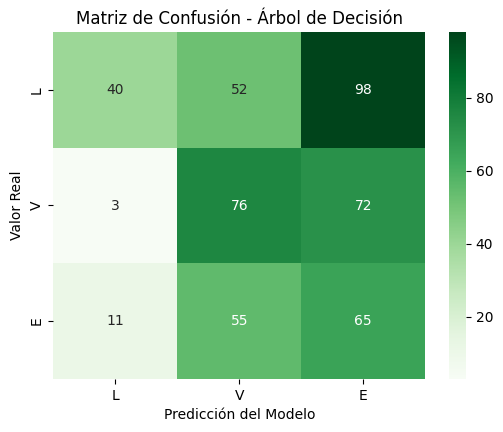

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generar la matriz usando y_test_encoded y los índices numéricos [0, 1, 2]
cm = confusion_matrix(y_test_encoded, y_pred, labels=[0, 1, 2])

# 2. Si definiste un LabelEncoder llamado 'le', podemos obtener el orden exacto de las clases:
# etiquetas_visibles = le.classes_  # Ejemplo: ['E', 'L', 'V']
# O si prefieres forzar el texto fijo en ese orden:
etiquetas_visibles = ["L", "V", "E"]

plt.figure(figsize=(6, 4.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=etiquetas_visibles,
    yticklabels=etiquetas_visibles,
)
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Valor Real")
plt.show()

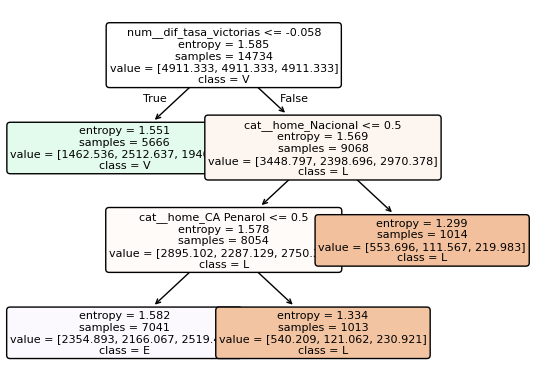

In [53]:
plot_tree(
    arbol_modelo_balanceado,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

## **Naive Bayes**

---

## - Implementamos y ajustamos Naive Bayes Manual

- m=1
- $p_c = 1/|valores|$


In [54]:
# IMPLEMENTACION MANUAL DEL NAIVE BAYES - ALGORITMO

class NaiveBayesManual(BaseEstimator, ClassifierMixin):

    def __init__(self, m=1):
        self.m = m

    # ENTRENAMIENTO

    def fit(self, X, y):
        # Reiniciar atributos cada vez que hacemos fit
        self.clases_ = None
        self.classes_ = None
        self.prior_clases_ = {}
        self.n_clase_ = {}
        self.valores_columnas_ = {}
        self.prob_condicionales_ = {}

        X = X.copy()

        if not isinstance(y, pd.Series):
            y = pd.Series(y, index=X.index)

        self.clases_ = np.unique(y)

        n_total = len(y)

        # Probabilidades a priori de las clases
        # P(Y = c)
        for clase in self.clases_:

            n_clase = np.sum(y == clase)

            self.n_clase_[clase] = n_clase

            self.prior_clases_[clase] = (
                n_clase / n_total
            )

        # Valores posibles de cada predictor
        for columna in X.columns:

            self.valores_columnas_[columna] = (
                np.unique(X[columna])
            )

        # Probabilidades condicionales
        # P(X_j = valor | Y = clase)

        for clase in self.clases_:

            X_clase = X[y == clase]

            n_clase = len(X_clase)

            self.prob_condicionales_[clase] = {}

            for columna in X.columns:

                self.prob_condicionales_[clase][columna] = {}

                valores = self.valores_columnas_[columna]

                k = len(valores)

                # Prior uniforme
                p = 1 / k

                for valor in valores:

                    n_valor = np.sum(
                        X_clase[columna] == valor
                    )

                    # m-estimador
                    prob = (
                        n_valor + self.m * p
                    ) / (
                        n_clase + self.m
                    )

                    self.prob_condicionales_[clase][columna][valor] = prob

        self.classes_ = self.clases_

        return self

    # PROBABILIDAD DE UNA OBSERVACIÓN

    def _log_prob_fila(self, fila, clase):

        log_prob = np.log(
            self.prior_clases_[clase]
        )

        for columna in fila.index:

            valor = fila[columna]

            valores = self.valores_columnas_[columna]
            k = len(valores)

            p = 1 / k

            # Si el valor apareció en entrenamiento
            if valor in self.prob_condicionales_[clase][columna]:

                prob = (
                    self.prob_condicionales_
                    [clase]
                    [columna]
                    [valor]
                )

            # Si aparece un valor nuevo en test
            else:

                n_clase = self.n_clase_[clase]

                # n_valor = 0
                prob = (
                    self.m * p
                ) / (
                    n_clase + self.m
                )

            log_prob += np.log(prob)

        return log_prob

    # PREDICCIÓN

    def predict(self, X):

        predicciones = []

        for _, fila in X.iterrows():

            log_probs = {}

            for clase in self.clases_:

                log_probs[clase] = (
                    self._log_prob_fila(
                        fila,
                        clase
                    )
                )

            prediccion = max(
                log_probs,
                key=log_probs.get
            )

            predicciones.append(prediccion)

        return np.array(predicciones)

In [55]:
#IMPLEMENTACION MANUAL DEL NAIVE BAYES - AJUSTE

X_train["home_tasa_victorias_nb"] =  X_train["home_tasa_victorias"].astype("category")
X_train["away_tasa_victorias_nb"] =  X_train["away_tasa_victorias"].astype("category")

X_test["home_tasa_victorias_nb"] =  X_test["home_tasa_victorias"].astype("category")
X_test["away_tasa_victorias_nb"] =  X_test["away_tasa_victorias"].astype("category")


features_nb = [
    'home',
    'away',
    'month',
    'home_tasa_victorias_nb',
    'away_tasa_victorias_nb'
]

# Seleccionar las variables que utilizará Naive Bayes
X_tr_nb = X_train[features_nb].copy()

X_te_nb = X_test[features_nb].copy()


# 2. Convertir y_train e y_test a Series
y_tr_nb = y_train["resultado"]
y_te_nb = y_test["resultado"]


# 3. Instanciar el modelo
nb_manual = NaiveBayesManual(m=1)


# 4. Entrenar
nb_manual.fit(X_tr_nb, y_tr_nb)


# 5. Predecir sobre test
y_pred_nb = nb_manual.predict(X_te_nb)


# 6. Evaluar
print(
    f"Accuracy Naive Bayes Manual: "
    f"{accuracy_score(y_te_nb, y_pred_nb):.4f}\n"
)

print(
    classification_report(
        y_te_nb,
        y_pred_nb
    )
)

Accuracy Naive Bayes Manual: 0.4597

              precision    recall  f1-score   support

           E       0.30      0.05      0.08       131
           L       0.46      0.76      0.58       190
           V       0.47      0.44      0.46       151

    accuracy                           0.46       472
   macro avg       0.41      0.42      0.37       472
weighted avg       0.42      0.46      0.40       472



## - Naive Bayes con sklearn

---

Comentarios:
- usar alpha pero sin suponer que es el m-estimador (no son lo mismo)
- Deberíamos hacerlo con el ordinal encoded. Si cambiamos eso, también hay que cambiar chunk de Comparación de modelos.

In [56]:
from sklearn.preprocessing import OrdinalEncoder

cat_cols = ["home", "away", "month"]
num_cols = ["home_tasa_victorias", "away_tasa_victorias"]

# Definir las transformaciones usando OrdinalEncoder
preprocessor_nb = ColumnTransformer(
    transformers=[
        (
            'cat',
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            cat_cols,
        ),
        ('num', 'passthrough', num_cols),
    ]
)

# Ajustar y transformar
X_train_encoded_nb = preprocessor_nb.fit_transform(X_train)
X_test_encoded_nb = preprocessor_nb.transform(X_test)

# Mapeo de la variable objetivo
mapa_resultados = {
    "L": 0,
    "V": 1,
    "E": 2,
}

# Seleccionamos la columna 'resultado'
y_train_encoded_nb = y_train["resultado"].map(mapa_resultados)
y_test_encoded_nb = y_test["resultado"].map(mapa_resultados)

=== Naive Bayes (m = 1.0) ===
Exactitud (Accuracy): 0.4640

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.48      0.69      0.57       190
           1       0.43      0.54      0.48       151
           2       0.56      0.04      0.07       131

    accuracy                           0.46       472
   macro avg       0.49      0.43      0.37       472
weighted avg       0.49      0.46      0.40       472



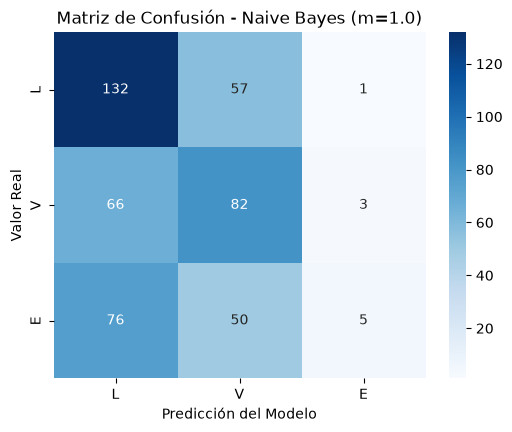

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# ==============================================================================
# IMPLEMENTACIÓN DE NAIVE BAYES (m-estimate)
# ==============================================================================

# 1. Definir el hiperparámetro m (tamaño equivalente de muestra)
m_param = 1.0

# Para CategoricalNB, alpha corresponde al suavizado de Laplace.
# Si consideramos p uniforme, ajustamos alpha = m_param
nb_modelo = CategoricalNB(alpha=m_param)

# 2. Entrenar el modelo
# Nota: CategoricalNB requiere datos de entrada categóricos discretos/codificados
nb_modelo.fit(X_train_encoded_nb, y_train_encoded_nb)

# 3. Predicción
y_pred_nb = nb_modelo.predict(X_test_encoded_nb)

# ==============================================================================
# EVALUACIÓN DEL MODELO
# ==============================================================================
print(f"=== Naive Bayes (m = {m_param}) ===")
print(f"Exactitud (Accuracy): {accuracy_score(y_test_encoded_nb, y_pred_nb):.4f}\n")

print("Reporte de Clasificación:")
print(classification_report(y_test_encoded_nb, y_pred_nb))

# Matriz de Confusión
cm_nb = confusion_matrix(y_test_encoded_nb , y_pred_nb, labels=[0, 1, 2])

plt.figure(figsize=(6, 4.5))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["L", "V", "E"],
    yticklabels=["L", "V", "E"],
)
plt.title(f"Matriz de Confusión - Naive Bayes (m={m_param})")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Valor Real")
plt.show()

## **Clasificador Base**

---

Comentarios:
- Debería hacerse con la columna date, no con year. Hay que buscar una forma de que no dropearla más arriba, pero sí especificar en el preprocess de los modelos, que las columnas de tipo date las ignoren.

In [57]:
from sklearn.base import BaseEstimator, ClassifierMixin


class Historico10AniosClassifier(BaseEstimator, ClassifierMixin):

    def __init__(self):
        self.win_ratios = {}
        self.clase_mayoritaria = None

    def fit(self, X, y):

        # Asegurar que y sea un vector unidimensional
        y = np.asarray(y).ravel()

        # 1. Clase mayoritaria global
        uniques, counts = np.unique(
            y,
            return_counts=True
        )

        self.clase_mayoritaria = uniques[
            np.argmax(counts)
        ]

        # 2. DataFrame auxiliar
        df = X.copy()
        df["ganador"] = y

        # 3. Últimos 10 años del conjunto de entrenamiento
        fecha_max = df["date"].max()
        fecha_inicio = fecha_max - pd.DateOffset(years=10)
        df_10y = df[
            (df["date"] > fecha_inicio) &
             (df["date"] <= fecha_max)
             ]

        # 4. Equipos presentes
        equipos = set(df_10y["home"]).union(
            set(df_10y["away"])
        )

        stats = {
            eq: {
                "jugados": 0,
                "ganados": 0
            }
            for eq in equipos
            if pd.notna(eq)
        }

        # 5. Contabilizar partidos y victorias
        for _, row in df_10y.iterrows():

            home = row["home"]
            away = row["away"]
            resultado = row["ganador"]

            # Local
            stats[home]["jugados"] += 1

            if resultado == "L":
                stats[home]["ganados"] += 1

            # Visitante
            stats[away]["jugados"] += 1

            if resultado == "V":
                stats[away]["ganados"] += 1

        # 6. Proporción de victorias
        self.win_ratios = {}

        for equipo, valores in stats.items():

            self.win_ratios[equipo] = (
                valores["ganados"]
                / valores["jugados"]
            )

        return self

    def predict(self, X):

        predictions = []

        for _, row in X.iterrows():

            home_ratio = self.win_ratios.get(
                row["home"],
                0.0
            )

            away_ratio = self.win_ratios.get(
                row["away"],
                0.0
            )

            if home_ratio > away_ratio:
                predictions.append("L")

            elif away_ratio > home_ratio:
                predictions.append("V")

            else:
                predictions.append(
                    self.clase_mayoritaria
                )

        return np.array(predictions)

## **Comparación de modelos**

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier

# 1. Diccionario modelos
modelos = {
    "Clasificador Base (Histórico 10 años)": Historico10AniosClassifier(),
    "Árbol de Decisión (sklearn)": DecisionTreeClassifier(
        criterion="entropy",
        class_weight="balanced",
        min_impurity_decrease=0.01,
        random_state=42,
    ),
    "Árbol de Decisión (Manual)": ArbolDecisionManual(
        min_info_gain=0.01, max_depth=5
    ),  # Árbol Manual
    "Naive Bayes (CategoricalNB)": CategoricalNB(alpha=1.0),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42
    ),
    "Naive Bayes (Manual)": NaiveBayesManual(m=1)  # Árbol Manual
}

resultados = {}

# 2. Entrenar y evaluar cada modelo
for nombre, model in modelos.items():
    if nombre == "Clasificador Base (Histórico 10 años)":
        # El clasificador base necesita las columnas sin codificar (incluyendo 'year')
        model.fit(X_train, y_train_encoded)
        y_pred = model.predict(X_test)

    elif nombre == "Naive Bayes (Manual)":

        # Naive Bayes manual usa las variables preparadas específicamente
        # para este modelo
        model.fit(X_tr_nb, y_train_encoded)
        y_pred = model.predict(X_te_nb)

    else:

        # Árbol sklearn, árbol manual, CategoricalNB y Random Forest
        # usan las matrices codificadas
        X_tr_scikit = X_train_encoded_arbol
        X_te_scikit = X_test_encoded_arbol

        model.fit(X_tr_scikit, y_train_encoded)
        y_pred = model.predict(X_te_scikit)

    # Accuracy
    acc = accuracy_score(y_test_encoded, y_pred)
    resultados[nombre] = acc

    print(f"==================================================")
    print(f"Modelo: {nombre}")
    print(f"Accuracy: {acc:.4f}\n")
    print(classification_report(y_test_encoded, y_pred))

# 3. Visualización comparativa de Accuracy
plt.figure(figsize=(9, 5))
bars = plt.barh(
    list(resultados.keys()), list(resultados.values()), color="skyblue"
)
plt.xlim(0, 1)
plt.xlabel("Accuracy")
plt.title("Comparativa de Modelos Supervisados")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.4f}",
        va="center",
    )

plt.tight_layout()
plt.show()

Modelo: Clasificador Base (Histórico 10 años)
Accuracy: 0.4025

              precision    recall  f1-score   support

           0       0.40      1.00      0.57       190
           1       0.00      0.00      0.00       151
           2       0.00      0.00      0.00       131

    accuracy                           0.40       472
   macro avg       0.13      0.33      0.19       472
weighted avg       0.16      0.40      0.23       472

Modelo: Árbol de Decisión (sklearn)
Accuracy: 0.3835

              precision    recall  f1-score   support

           0       0.74      0.21      0.33       190
           1       0.42      0.50      0.46       151
           2       0.28      0.50      0.36       131

    accuracy                           0.38       472
   macro avg       0.48      0.40      0.38       472
weighted avg       0.51      0.38      0.38       472



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Modelo: Árbol de Decisión (Manual)
Accuracy: 0.4640

              precision    recall  f1-score   support

           0       0.44      0.97      0.60       190
           1       0.73      0.22      0.34       151
           2       0.50      0.01      0.02       131

    accuracy                           0.46       472
   macro avg       0.56      0.40      0.32       472
weighted avg       0.55      0.46      0.35       472



ValueError: Negative values in data passed to CategoricalNB (input X).

# 3. EXPERIMENTACIÓN

- Falta Random Forest
- Va Árbol de Decisión?
- Implementar CV por ventanas móviles que tome en cuenta temporalidad
- Si modelo base ya está en parte 2, no se agrega, no? Quizás imprimir de nuevo matriz de confusión y/o métricas
- Tunear mejor hiperparámetros
- Agregar hiperparámetros a NB?
- Falta features selection
- Falta graficar error según valores de cada hiperparámetro
- Para resultados de test faltan: todas las otras métricas (precisión, recall, F1 por clase y macro-F1) y matrices de confusión

In [59]:

import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    FunctionTransformer
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import CategoricalNB

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


---

## - Definimos pipeline de preprocesamiento para cada modelo según las variables que vaya a usar y las transformaciones específicas

Comentario: Agregamos balanceo a NB con sklearn?

In [60]:


# VARIABLES PARA LOS ÁRBOLES
numeric_features_arbol = [
    "year",
    "month",
    "home_tasa_victorias",
    "away_tasa_victorias",
    "dif_tasa_victorias"
]

categorical_features_arbol = [
    "home",
    "away"
]

features_arbol = (
    numeric_features_arbol
    + categorical_features_arbol
)

# VARIABLES PARA NAIVE BAYES
#    Sin dif_tasa_victorias
features_nb = [
    "home",
    "away",
    "month",
    "home_tasa_victorias",
    "away_tasa_victorias"
]

# date:
#   se conserva para CV temporal, pero no es predictor

# year, dif_tasa_victorias:
#   se usan en árboles, pero no en Naive Bayes


In [61]:
# Pipeline para modelos de Árbol
preprocessing_arbol = ColumnTransformer([
    ("numeric", "passthrough", numeric_features_arbol),
    ("categorical", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            drop=None
        ),
        categorical_features_arbol
    )
])

# Pipeline para modelo NB con sklearn
preprocessing_nb_sklearn = Pipeline([
    (
        "ordinal", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1)
    ),
    (
        "hacer_no_negativos",
        FunctionTransformer(
            lambda X: X + 1
        )
    )
])

In [62]:
# Pipeline Árbol sklearn
pipeline_arbol_sklearn = Pipeline([
    ("preprocessing", preprocessing_arbol),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Pipeline Árbol manual
pipeline_arbol_manual = Pipeline([
    ("preprocessing",preprocessing_arbol),
    ("model", ArbolDecisionManual())
])

# Pipeline NB sklearn
pipeline_nb_sklearn = Pipeline([
    ("preprocessing", preprocessing_nb_sklearn),
    ("model", CategoricalNB())
])

# Pipeline NB manual
pipeline_nb_manual = Pipeline([
    ("model", NaiveBayesManual())
])

# Pipeline RF sklearn
# falta


## - Definimos Grilla de valores a probar por hiperparámetro

In [63]:
# Grilla Árbol sklearn
param_grid_arbol_sklearn = {

    "model__min_impurity_decrease": [
        0.0,
        0.005,
        0.01,
        0.05
    ],

    "model__max_depth": [
        3,
        5,
        10,
        None
    ],

    "model__min_samples_leaf": [
        1,
        10,
        50,
        200
    ]
}

# Grilla Árbol manual
param_grid_arbol_manual = {

    "model__min_info_gain": [
        0.0,
        0.005,
        0.01,
        0.05
    ],

    "model__max_depth": [
        3,
        5,
        10,
        None
    ]
}

# Grilla NB sklearn
param_grid_nb_sklearn = {

    "model__alpha": [
        0.01,
        0.1,
        1,
        5,
        10
    ],

    "model__fit_prior": [
        True, #prob a priori es proporción de datos de train de cada clase
        False #prob a priori se asume uniforme
    ]
}

# Grilla NB manual
param_grid_nb_manual = {

    "model__m": [
        0.1,
        0.5,
        1,
        5,
        10
    ]
}


## - Definimos función de validación cruzada con ventanas móviles de 1 año, que serían los folds para validar
## - Se definen 10 folds usando los datos de hasta 2014, datos más antiguos pueden ser contraproducentes

In [64]:
# CV temporal con ventanas móviles de 1 año

def crear_cv_temporal_date(
    X,
    fechas_inicio_validacion
):

    fechas = pd.to_datetime(
        X["date"]
    )

    splits = []

    for fecha_inicio in fechas_inicio_validacion:

        fecha_inicio = pd.Timestamp(
            fecha_inicio
        )

        fecha_fin = (
            fecha_inicio
            + pd.DateOffset(years=1)
        )

        # Train:
        # todo lo anterior a la ventana de validación
        train_idx = np.where(
            fechas < fecha_inicio
        )[0]

        # Validation:
        # un año completo
        val_idx = np.where(
            (fechas >= fecha_inicio)
            &
            (fechas < fecha_fin)
        )[0]

        splits.append(
            (train_idx, val_idx)
        )

    return splits

In [65]:
fechas_validacion = [
    # "2014-01-01",
    # "2015-01-01",
    # "2016-01-01",
    # "2017-01-01",
    # "2018-01-01",
    "2019-01-01",
    "2020-01-01",
    "2021-01-01",
    "2022-01-01",
    "2023-01-01"
]# Mejor ajustar con los años más recientes.
# 10 folds de 1 año y se entrena con toda los datos anteriores

cv_temporal = crear_cv_temporal_date(
    X_train,
    fechas_validacion
)

## - Ajustamos cada modelo según la búsqueda por grilla y obtenemos los mejores hiperparámetros
## - El modelo con los hiperparámetros que minimizan el error se reentrena usando todo el dataset de train
---

Comentario:
- Sería mejor usar grillas más amplias y random search? Si no, achicar grillas porque demora mucho

In [66]:
# Función de ajuste

def ajustar_modelo(
    pipeline,
    param_grid,
    X,
    y,
    cv
):

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="accuracy",
        cv=cv,
        n_jobs=-1, # permite paralelizar combinaciones/folds
        refit=True, # el mejor modelo se vuelve a entrenar con todos los datos de train
        return_train_score=True
    )

    grid.fit(
        X,
        np.asarray(y).ravel()
    )

    return grid

Comentario: arbol manual demora un montón aún con pocos hiperparámetros. Probar en otro momento si termina. Si no, probar quitarle atributos y si no, revisar código por si hay algún bug

In [ ]:
# Ajuste Árbol sklearn
grid_arbol_sklearn = ajustar_modelo(
    pipeline=pipeline_arbol_sklearn,
    param_grid=param_grid_arbol_sklearn,
    X=X_train[features_arbol],
    y=y_train["resultado"],
    cv=cv_temporal
)

print("Árbol sklearn terminó")

# Ajuste Árbol manual
grid_arbol_manual = ajustar_modelo(
    pipeline=pipeline_arbol_manual,
    param_grid=param_grid_arbol_manual,
    X=X_train[features_arbol],
    y=y_train["resultado"],
    cv=cv_temporal
) # demora mucho, comentar

print("Árbol manual terminó")

# Ajuste NB sklearn
grid_nb_sklearn = ajustar_modelo(
    pipeline=pipeline_nb_sklearn,
    param_grid=param_grid_nb_sklearn,
    X=X_train[features_nb],
    y=y_train["resultado"],
    cv=cv_temporal
)

print("NB sklearn terminó")

# Ajuste NB manual
grid_nb_manual = ajustar_modelo(
    pipeline=pipeline_nb_manual,
    param_grid=param_grid_nb_manual,
    X=X_train[features_nb],
    y=y_train["resultado"],
    cv=cv_temporal
)

print("NB manual terminó")

NameError: name 'cv_temporal' is not defined

In [ ]:
# Mostrar mejores hiperparámetros

print("ÁRBOL SKLEARN")
print(
    grid_arbol_sklearn.best_params_
)
print(
    "Accuracy CV:",
    grid_arbol_sklearn.best_score_
)


print("\nÁRBOL MANUAL")
print(
    grid_arbol_manual.best_params_
)
print(
    "Accuracy CV:",
    grid_arbol_manual.best_score_
)


print("\nCATEGORICAL NB")
print(
    grid_nb_sklearn.best_params_
)
print(
    "Accuracy CV:",
    grid_nb_sklearn.best_score_
)


print("\nNAIVE BAYES MANUAL")
print(
    grid_nb_manual.best_params_
)
print(
    "Accuracy CV:",
    grid_nb_manual.best_score_
)

ÁRBOL SKLEARN


NameError: name 'grid_arbol_sklearn' is not defined

## - Graficamos errores según cada valor de los hiperparámetros

In [ ]:
# Gráfico de error por hiperparámetro

def plot_error_hiperparametro(
    grid,
    parametro,
    titulo
):

    resultados = pd.DataFrame(
        grid.cv_results_
    )

    columna_parametro = (
        f"param_{parametro}"
    )

    resumen = (
        resultados
        .groupby(
            columna_parametro,
            dropna=False
        )["mean_test_score"]
        .mean()
        .reset_index()
    )

    resumen["error"] = (
        1
        - resumen["mean_test_score"]
    )

    plt.figure(
        figsize=(7, 4)
    )

    plt.plot(
        resumen[columna_parametro]
        .astype(str),
        resumen["error"],
        marker="o"
    )

    plt.xlabel(parametro)

    plt.ylabel(
        "Error = 1 - Accuracy"
    )

    plt.title(titulo)

    plt.show()

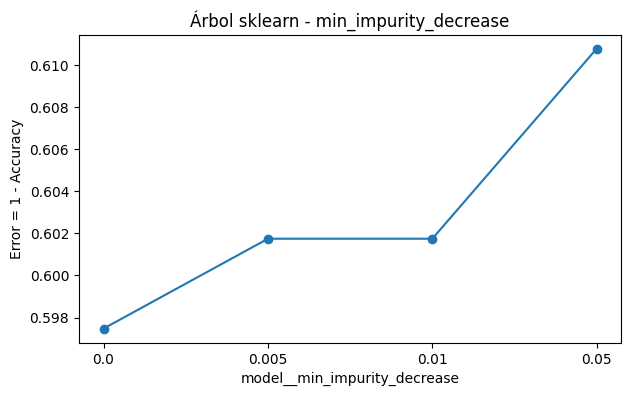

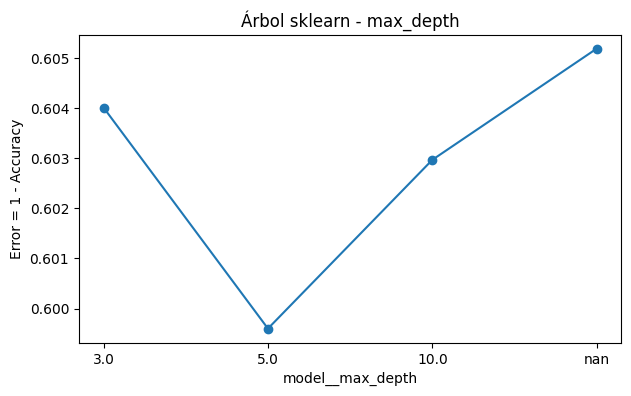

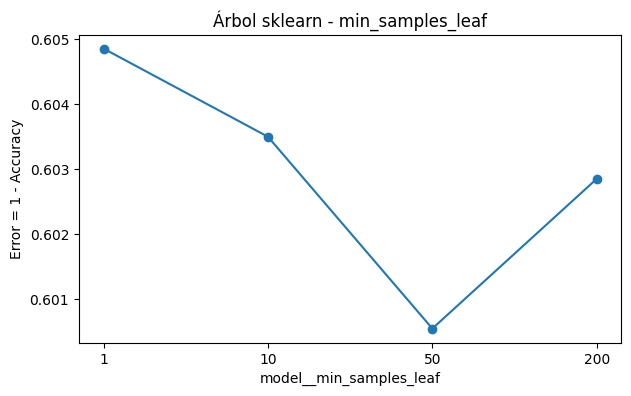

In [ ]:
# Plot errores Árbol sklearn

plot_error_hiperparametro(
    grid_arbol_sklearn,
    "model__min_impurity_decrease",
    "Árbol sklearn - min_impurity_decrease"
)

plot_error_hiperparametro(
    grid_arbol_sklearn,
    "model__max_depth",
    "Árbol sklearn - max_depth"
)

plot_error_hiperparametro(
    grid_arbol_sklearn,
    "model__min_samples_leaf",
    "Árbol sklearn - min_samples_leaf"
)

In [ ]:
# Plot errores Árbol manual
plot_error_hiperparametro(
    grid_arbol_manual,
    "model__min_info_gain",
    "Árbol manual - min_info_gain"
)

plot_error_hiperparametro(
    grid_arbol_manual,
    "model__max_depth",
    "Árbol manual - max_depth"
)

NameError: name 'grid_arbol_manual' is not defined

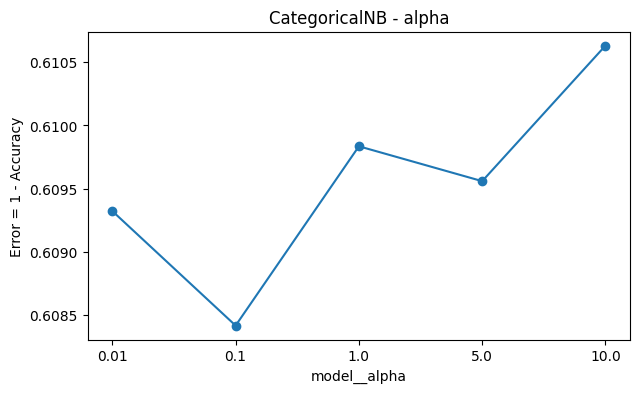

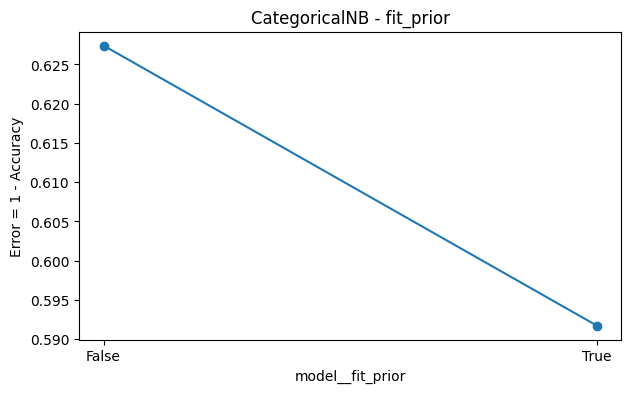

In [ ]:
# Plot errores NB sklearn
plot_error_hiperparametro(
    grid_nb_sklearn,
    "model__alpha",
    "CategoricalNB - alpha"
)

plot_error_hiperparametro(
    grid_nb_sklearn,
    "model__fit_prior",
    "CategoricalNB - fit_prior"
)

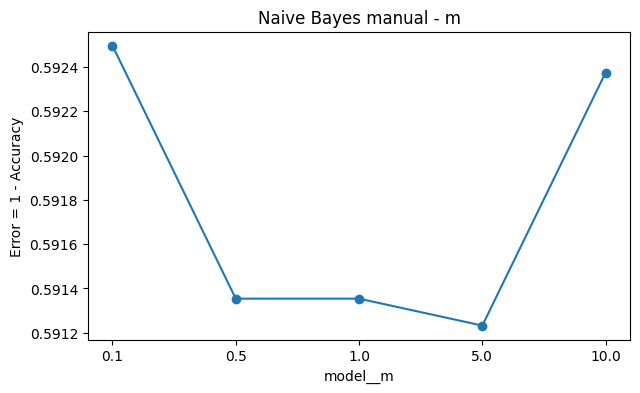

In [ ]:
# Plot errores NB manual
plot_error_hiperparametro(
    grid_nb_manual,
    "model__m",
    "Naive Bayes manual - m"
)

## - Clasificador base (nuevamente), no lleva ajuste de hiperparámetros

---

Comentarios:
- Esta parte la saco y muestro solo los resultados del modelo ya ajustado en parte 2?


In [ ]:
# Clasificador base

baseline = Historico10AniosClassifier()

baseline.fit(
    X_train,
    y_train["resultado"]
)

Historico10AniosClassifier()

## - Evaluamos en set de testeo y comparamos las métricas precisión, recall, F1 por clase, accuracy y macro-F1

Comentario:
- Falta RF
- Falta matriz de confusión para todos

In [ ]:

# Evaluación en set de testeo
def evaluar_modelo(
    nombre,
    modelo,
    X_test_modelo,
    y_test
):

    y_true = np.asarray(
        y_test
    ).ravel()

    y_pred = modelo.predict(
        X_test_modelo
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    print("=" * 60)
    print(nombre)
    print("=" * 60)

    print(
        f"Accuracy: {accuracy:.4f}"
    )

    print(
        f"Macro-F1: {macro_f1:.4f}\n"
    )

    print(
        classification_report(
            y_true,
            y_pred,
            digits=4
        )
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[
            "L",
            "E",
            "V"
        ]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "L",
            "E",
            "V"
        ]
    )

    disp.plot()

    plt.title(
        f"Matriz de confusión - {nombre}"
    )

    plt.show()

    return {
        "modelo": nombre,
        "accuracy": accuracy,
        "macro_f1": macro_f1
    }

In [ ]:
resultados = []

Árbol sklearn
Accuracy: 0.4576
Macro-F1: 0.3476

              precision    recall  f1-score   support

           E     0.0000    0.0000    0.0000       131
           L     0.4808    0.7263    0.5786       190
           V     0.4216    0.5166    0.4643       151

    accuracy                         0.4576       472
   macro avg     0.3008    0.4143    0.3476       472
weighted avg     0.3284    0.4576    0.3814       472



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


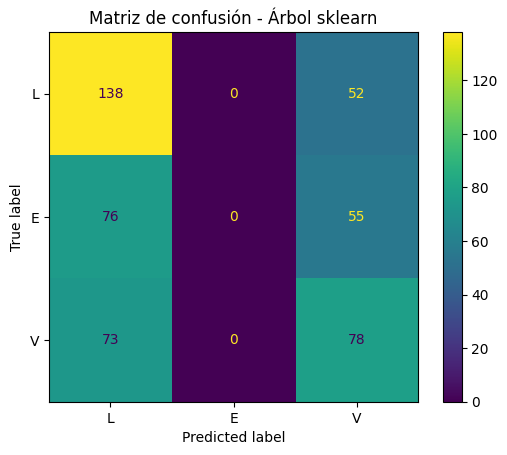

In [ ]:
# Evaluación del  Árbol sklearn

resultados.append(
    evaluar_modelo(
        "Árbol sklearn",
        grid_arbol_sklearn.best_estimator_,
        X_test[features_arbol],
        y_test["resultado"]
    )
)

In [ ]:
# Evaluación del  Árbol manual

resultados.append(
    evaluar_modelo(
        "Árbol manual",
        grid_arbol_manual.best_estimator_,
        X_test[features_arbol],
        y_test["resultado"]
    )
)

CategoricalNB
Accuracy: 0.4703
Macro-F1: 0.3706

              precision    recall  f1-score   support

           E     0.2000    0.0153    0.0284       131
           L     0.4927    0.7105    0.5819       190
           V     0.4521    0.5629    0.5015       151

    accuracy                         0.4703       472
   macro avg     0.3816    0.4296    0.3706       472
weighted avg     0.3985    0.4703    0.4025       472



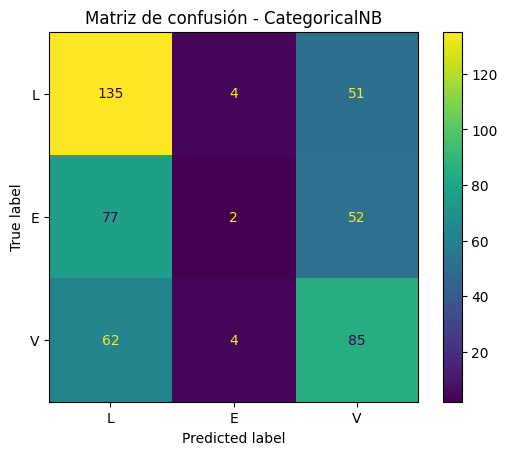

In [ ]:
# Evaluación del  NB sklearn

resultados.append(
    evaluar_modelo(
        "CategoricalNB",
        grid_nb_sklearn.best_estimator_,
        X_test[features_nb],
        y_test["resultado"]
    )
)

Naive Bayes manual
Accuracy: 0.4619
Macro-F1: 0.3691

              precision    recall  f1-score   support

           E     0.2143    0.0229    0.0414       131
           L     0.4887    0.6842    0.5702       190
           V     0.4427    0.5629    0.4956       151

    accuracy                         0.4619       472
   macro avg     0.3819    0.4233    0.3691       472
weighted avg     0.3978    0.4619    0.3996       472



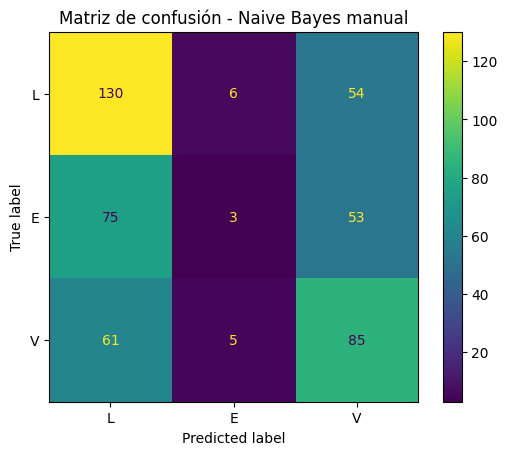

In [ ]:
# Evaluación del NB manual

resultados.append(
    evaluar_modelo(
        "Naive Bayes manual",
        grid_nb_manual.best_estimator_,
        X_test[features_nb],
        y_test["resultado"]
    )
)

Clasificador base - histórico 10 años
Accuracy: 0.4682
Macro-F1: 0.3613

              precision    recall  f1-score   support

           E     0.0000    0.0000    0.0000       131
           L     0.5125    0.6474    0.5721       190
           V     0.4224    0.6490    0.5117       151

    accuracy                         0.4682       472
   macro avg     0.3116    0.4321    0.3613       472
weighted avg     0.3414    0.4682    0.3940       472



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


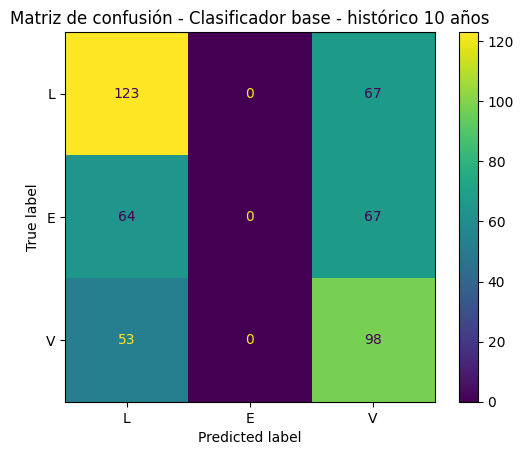

In [ ]:
# Evaluación del Clasificador Base

resultados.append(
    evaluar_modelo(
        "Clasificador base - histórico 10 años",
        baseline,
        X_test,
        y_test["resultado"]
    )
)

In [ ]:
# Tabla comparativa

resultados_df = pd.DataFrame(
    resultados
)

resultados_df = (
    resultados_df
    .sort_values(
        "accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

print(resultados_df)

                                  modelo  accuracy  macro_f1
0                          CategoricalNB  0.470339  0.370580
1  Clasificador base - histórico 10 años  0.468220  0.361281
2                     Naive Bayes manual  0.461864  0.369061
3                          Árbol sklearn  0.457627  0.347634
